1. Di langkah ini, kita akan mengecek spesifikasi mesin Google Colab yang sedang digunakan. Tujuannya untuk memastikan versi Python, library, serta kapasitas RAM dan memori sudah sesuai dengan kebutuhan komputasi kita.

In [82]:
import sys, platform, multiprocessing

print("Python   :", sys.version.split()[0])
print("OS       :"), platform.platform()
print("CPU core :", multiprocessing.cpu_count())


for name in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(name)
    print(f"{name:11s}: {mod.__version__}")
  except ImportError:
    print(f"{name:11s}: BELUM TERPASANG")

!free -h            #kapasistas dan sisa RAM
!df -h /content     #kapasistas dan sisa disk runtime
!java -version      #dibutuhkan PySpark pada langkah K-8


Python   : 3.13.15
OS       :
CPU core : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       4.1Gi       6.3Gi        15Mi       2.7Gi       8.6Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.004s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.004s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


2. Kode ini berfungsi untuk menyambungkan Google Colab dengan Google Drive. Setelah terhubung, kita membuat folder khusus agar semua hasil pekerjaan tersimpan aman dan tidak hilang saat Colab ditutup.

In [83]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_KERJA))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['yellow_tripdata_2023-01.parquet', 'trips.csv']


3. Kita membuat sebuah fungsi khusus untuk memantau seberapa lama waktu eksekusi dan berapa besar memori RAM yang dipakai oleh sistem. Alat ukur ini sangat penting untuk membuktikan mana strategi pengolahan data yang paling efisien nanti.

In [84]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []      #menyimpan hasil pengukran untuk dibandingkan nanti


def rss_mb():
  return proses.memory_info().rss / 1024**2


def ukur(label, fungsi):
  " ""Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori." " "
  m0, t0 = rss_mb(), time.perf_counter()
  hasil =fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik,2),
                  "delta_rss.mb": round(delta,1)})
  print(f"[{label}] {detik:2f} s | RSS {delta:+.1f} MB")
  return hasil

4. Mengunduh dataset dan inspeksi awal,
Langkah ini bertujuan mengunduh dataset perjalanan taksi New York secara otomatis dari internet. Setelah terunduh, kita mengecek sekilas info datanya seperti ukuran file dan nama kolom tanpa harus memuat keseluruhan datanya ke dalam memori.

In [85]:
import urllib.request

URL =("https://d37ci6vzurychx.cloudfront.net/trip-data/"
"yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024 ** 2, 1), "MB")

Ukuran file: 45.5 MB


In [86]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("jumlah baris : ", f"{meta.num_rows:,}")
print("jumlah kolom : ", meta.num_columns)
print("row group    : ", meta.num_row_groups)
print("nama kolom   : ", pq.ParquetFile(PATH).schema.names)

jumlah baris :  3,066,766
jumlah kolom :  19
row group    :  1
nama kolom   :  ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


4b. Jalur cadangan bila unduhan gagal
Ini adalah kode opsional yang hanya dijalankan jika file dataset asli gagal diunduh akibat kendala jaringan. Kode ini akan men-generate data taksi buatan (sintetis) agar praktikum tetap bisa dilanjutkan.

In [87]:
import numpy as np
import pandas as pd

def bangkitkan_sintetis(n=5_000_000, seed=42):
  rng   = np.random.default_rng(seed)
  awal  = pd.timestamp("2023-01-01")
  pickup = awal + pd.tp_timedelta(rng.integers(0, 31*24*60, n), unit="m")
  durasi = rng.integers(1, 90, n)
  return pd.DataFrame({
      "tpep_pickup_datetime": pickup,
      "tpep_dropoff_datetime": pickup + pd.tp_timedelta(durasi, unit="m"),
      "passenger_count": rng.integers(1,5, n).astype("float64"),
      "trip_distance": np.round(rng.gamma(2.0, 1.6, n), 2),
      "payment_type": rng.integers(1,5, n).astype("int64"),
      "fare_amount": np.round(rng.gamma(4.0, 3.0, n), 2),
      "tip_amount": np.round(rng.gamma(1.5, 1.2, n), 2),
  }). assign(totel_amount=lambda d: (d.fare_amount + d.tip_amount + 3.0). round(2))

if not os.path.exists(PATH):
  bangkitkan_sintetis().to_parquet(PATH, index=false)
  print("dataset sintetis dibuat di", PATH)

5. Memuat data dan mengukur biaya memorinya
Di sini kita akan membuktikan bahwa memuat sebagian kolom saja jauh lebih hemat memori dibandingkan memuat seluruh kolom. Kita juga akan mengecilkan tipe data misalnya mengubah angka tipe float64 menjadi float32 agar beban RAM semakin ringan.

In [88]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
"passenger_count", "trip_distance", "payment_type",
"fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet (PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")
df.head()


df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024 ** 2

# MB per kolom

sebelum = df.memory_usage(deep=True).sum() / 1024
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum :.1f} MB -> {sesudah :.1f} MB (hemat {100*(1-sesudah/sebelum) :.1f}%)")
df.dtypes



[baca semua kolom] 2.192315 s | RSS +424.4 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.647397 s | RSS +163.8 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB
191673.0 MB -> 119.9 MB (hemat 99.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


6. Pemeriksaan kualitas data dan pembersihan veracity
Data mentah seringkali memiliki error, jadi kita perlu menyaring dan membuang baris data yang anomali seperti jarak tempuh minus atau durasi yang tidak masuk akal. Pembersihan ini wajib dilakukan agar hasil akhir analisis kita bisa dipercaya.

In [89]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount",]].describe())
print("\nNilai kosong per kolom :\n", df.isna().sum())

anomali = {
    "jarak <=0"     : (df["trip_distance"] <= 0).sum(),
    "durasi <=0"    : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"    : (df["durasi_menit"] > 180).sum(),
    "total_amoun <= 0"      : (df["total_amount"] <= 0).sum()
}

for k,v in anomali.items():
  print (f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0 & (df["trip_distance"] < 100)  &
     df["durasi_menit"].between(1,180)) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris ( dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom :
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <=0             : 45,862 baris (1.50%)
durasi <=0            : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amoun <= 0      : 25,772 baris (0.84%)
3,066,766 baris -> 2,998,642 baris ( dibuang 68,124)


7. Memproses file lebih besar dari memori dengan chunking
Langkah ini mensimulasikan cara kita mengolah data raksasa yang ukurannya melebihi kapasitas RAM. Caranya adalah dengan teknik chunking, yaitu membaca dan memproses file tersebut secara bertahap dicicil agar Colab tidak crash.

In [90]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024 ** 2, 1), "MB")
print("CSV   :", round(os.path.getsize(CSV) / 1024 ** 2, 1), "MB")

[tulis CSV] 46.537366 s | RSS +0.0 MB
Parquet: 45.5 MB
CSV   : 227.1 MB


In [91]:
def agregasi_bertahap(path, ukuran_cunk=500_000):
  jumlah_baris = 0
  total_nilai  = 0.0
  per_jam      = {}
  potongan = pd.read_csv(
      path,
      usecols=["tpep_pickup_datetime", "total_amount"],
      parse_dates=["tpep_pickup_datetime"],
      chunksize=ukuran_chunk)
  for chunk in potongan:
      jumlah_baris += len(chunk)
      total_nilai += chunk["total_amount"].sum()
      for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
        n, nilai = per_jam.get(jam, (0,0.0))
        per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
  return jumlah_baris, total_nilai, per_jam

  baris, total, per_jam_chunk = ukur("agregasi chunkin", lambda: agregasi_bertahap(CSV))
  print(f"{baris:,} baris | rata rata total_amount - {total/baris:.2f}")



8. Pendekatan terdistribusi: PySpark local mode
Kita akan mencoba memproses data yang sama menggunakan PySpark untuk melihat cara kerja sistem terdistribusi. Eksperimen ini juga akan membuktikan bahwa untuk ukuran data yang relatif kecil, pemrosesan terdistribusi Spark justru bisa lebih lambat daripada pandas biasa.

In [92]:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [93]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
              .withColumn(
                  "durasi_menit",
                  #code yang salah
                  #(F.col("tpep_dropoff_datetime").cast("long")
                  #- F.col("tpep_pickup_datetime").cast("long")) / 60

                  (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
                  - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60
              )
              .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
              .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
              .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
                 .withColumn("jam", F.hour("tpep_pickup_datetime"))
                 .groupBy("jam")
                 .agg(F.count("*").alias("jumlah"),
                      F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
                      F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
                 .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")

spark.sql("""
      SELECT payment_type,
            COUNT(*)                    AS jumlah,
            ROUND(AVG(total_amount), 2) AS rata_tarif,
            ROUND(AVG(tip_amount), 2)   AS rata_tip
      FROM trips
      GROUP BY payment_type
      ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.441172 s | RSS +0.0 MB
jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jara

9. Agregasi akhir dengan pandas dan penyimpanan
Setelah data dibersihkan, kita mengelompokkan data berdasarkan jam penjemputan untuk mencari metrik penting seperti rata-rata tarif dan jarak. Hasil ringkasan ini kemudian diekspor ke Google Drive dalam bentuk format CSV dan Parquet.

In [94]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
            .groupby("jam")
            .agg(jumlah_perjalanan=("total_amount", "size"),
                 rata_jarak=("trip_distance", "mean"),
                 rata_durasi=("durasi_menit", "mean"),
                 rata_tarif=("total_amount", "mean"),
                 median_tarif=("total_amount", "median"))
            .round(2)
            .reset_index()
            .sort_values("jam"))

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82728,4.09,15.66,28.879999,21.500000
1,1,58114,3.56,14.92,26.450001,21.200001
2,2,40719,3.27,14.68,25.059999,20.520000
3,3,26357,3.86,14.66,26.290001,20.900000
4,4,16825,4.99,15.78,31.770000,22.700001
5,5,17093,16.07,15.64,36.820000,22.000000
6,6,42512,5.55,15.12,30.670000,18.480000
7,7,84896,5.35,15.15,26.920000,18.480000
8,8,114489,5.62,15.73,25.240000,19.100000
9,9,128453,3.17,15.32,25.540001,19.250000


10. Visualisasi hasil
Langkah terakhir adalah mengubah tabel ringkasan data tadi menjadi sebuah grafik batang. Melalui visualisasi ini, kita bisa melihat dengan jelas pada jam berapa permintaan taksi paling tinggi.

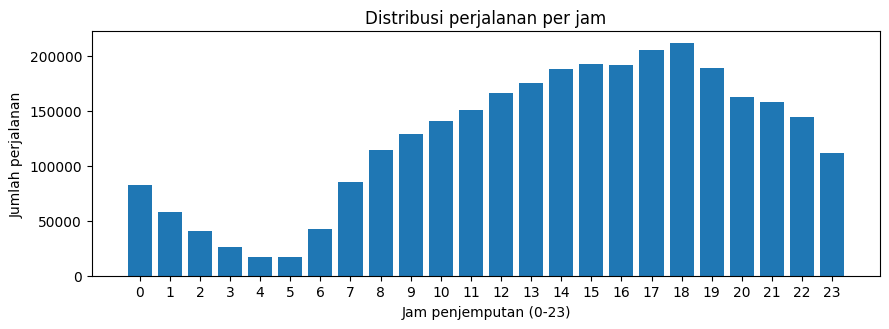

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Analisis hasil menggunakan tabel dari dataframe.

In [96]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss.mb
0,baca semua kolom,2.19,424.4
1,baca kolom terpilih,0.65,163.8
2,tulis CSV,46.54,0.0
3,spark count,0.44,0.0
4,spark agregasi,3.64,0.0


Studi kasus

angkah ini digunakan untuk mengelompokkan data berdasarkan status akhir pekan dan jam, lalu menghitung jumlah perjalanan, rata-rata durasi, serta rata-rata tarif per menit.

In [97]:
import matplotlib.pyplot as plt
import numpy as np

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)
bersih["tarif_per_menit"] = bersih["tarif_per_menit"].replace([np.inf, -np.inf], 0)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index()
)

print(ringkas.head(12))

    akhir_pekan  jam  jumlah  rata_durasi  rata_tarif_per_menit
0         False    0   35588        16.00                  3.42
1         False    1   17646        14.66                  4.01
2         False    2    9540        14.50                  4.04
3         False    3    6298        14.95                  4.19
4         False    4    6289        16.90                  7.10
5         False    5   12559        15.10                  5.53
6         False    6   35890        15.25                  3.06
7         False    7   74403        15.37                  2.78
8         False    8   98763        16.33                  2.39
9         False    9  103638        16.19                  2.48
10        False   10  105568        16.22                  2.47
11        False   11  109126        16.15                  2.45


Langkah ini digunakan untuk memvisualisasikan pola permintaan taksi per jam dengan membandingkan jumlah perjalanan pada hari kerja dan akhir pekan.

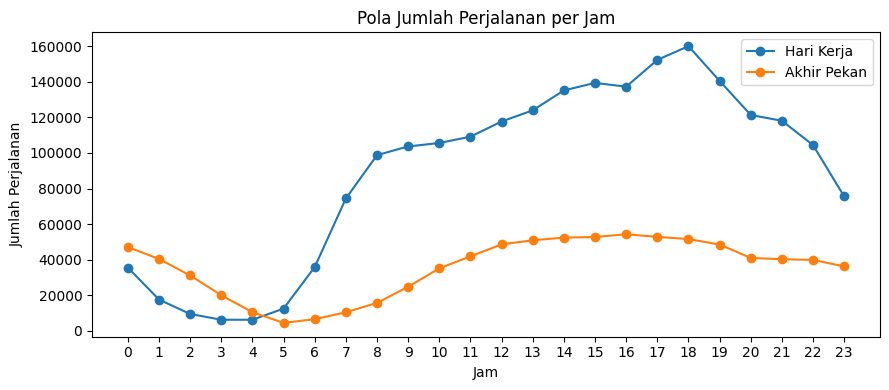

In [98]:
hari_kerja = ringkas[ringkas['akhir_pekan'] == False]
akhir_pekan = ringkas[ringkas['akhir_pekan'] == True]

plt.figure(figsize=(9, 4))
plt.plot(hari_kerja['jam'], hari_kerja['jumlah'], label='Hari Kerja', marker='o')
plt.plot(akhir_pekan['jam'], akhir_pekan['jumlah'], label='Akhir Pekan', marker='o')
plt.title('Pola Jumlah Perjalanan per Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Perjalanan')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

Langkah ini digunakan untuk memvisualisasikan hubungan antara rata-rata durasi perjalanan dan rata-rata tarif per menit berdasarkan jam penjemputan pada hari kerja dan akhir pekan.

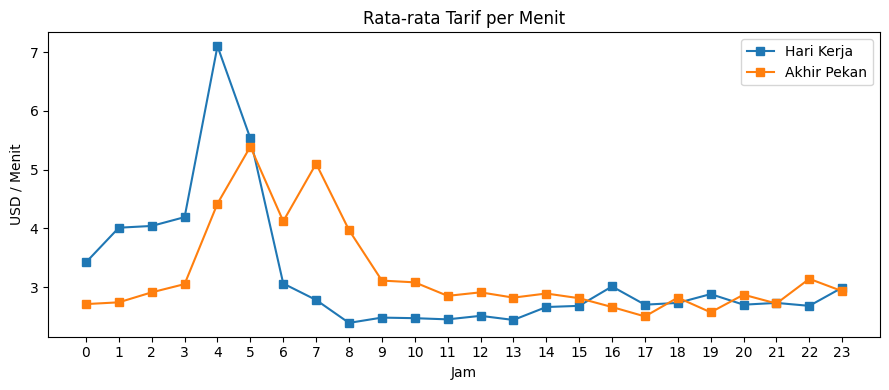

In [99]:
plt.figure(figsize=(9, 4))
plt.plot(hari_kerja['jam'], hari_kerja['rata_tarif_per_menit'], label='Hari Kerja', marker='s')
plt.plot(akhir_pekan['jam'], akhir_pekan['rata_tarif_per_menit'], label='Akhir Pekan', marker='s')
plt.title('Rata-rata Tarif per Menit')
plt.xlabel('Jam')
plt.ylabel('USD / Menit')
plt.xticks(range(0, 24)) # Memaksa sumbu X menampilkan semua jam
plt.legend()
plt.tight_layout()
plt.show()

Latihan


Langkah ini digunakan mencari lima perjalanan dengan nilai trip_distance terbesar dari data yang telah dibersihkan

In [100]:
top_5_distance = bersih.nlargest(5, 'trip_distance')
print(top_5_distance[['trip_distance', 'durasi_menit', 'total_amount']])

         trip_distance  durasi_menit  total_amount
3046991      258928.15           6.0     21.180000
3009826      225987.37          29.0     72.589996
3027106      187872.33          10.0     21.620001
3021750      116439.71           9.0     20.219999
3064729       85543.66          39.0     51.799999


Langkah ini mengulangi proses chunking dengan dua ukuran potongan data yang berbeda. Waktu eksekusi dan perubahan penggunaan memori dibandingkan untuk melihat trade-off antara ukuran chunk, waktu pemrosesan, dan penggunaan memori.

In [101]:
import pandas as pd
def agregasi_bertahap_revisi(path, ukuran_chunk):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

CSV_path = f"{DIR_KERJA}/trips.csv"
baris_100k, total_100k, per_jam_100k = ukur("chunk 100_000", lambda: agregasi_bertahap_revisi(CSV_path, 100_000))
baris_1m, total_1m, per_jam_1m = ukur("chunk 1_000_000", lambda: agregasi_bertahap_revisi(CSV_path, 1_000_000))

[chunk 100_000] 6.773798 s | RSS +4.0 MB
[chunk 1_000_000] 6.058641 s | RSS +21.3 MB


Langkah ini untuk menghitung persentase tip terhadap fare_amount untuk setiap perjalanan, kemudian rata-rata persentase tip dibandingkan berdasarkan metode pembayaran.

In [102]:
import numpy as np
bersih['persen_tip'] = np.where(
    bersih['fare_amount'] == 0,
    0,
    (bersih['tip_amount'] / bersih['fare_amount']) * 100
)

rata_tip = bersih.groupby('payment_type')['persen_tip'].mean().round(2)
print("Rata-rata persen tip per metode pembayaran:")
print(rata_tip)

Rata-rata persen tip per metode pembayaran:
payment_type
0    20.219999
1    25.969999
2     0.000000
3     0.020000
4     0.140000
Name: persen_tip, dtype: float32


/tmp/ipykernel_729/2446345239.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby('payment_type')['persen_tip'].mean().round(2)


Langkah ini untuk menyimpan data bersih dalam format Parquet menggunakan kompresi Snappy dan Gzip, kemudian membandingkannya.

In [103]:
import os

ukur("Simpan Snappy", lambda: bersih.to_parquet(f"{DIR_SIMPAN}/bersih_snappy.parquet", compression='snappy'))
ukur("Simpan Gzip", lambda: bersih.to_parquet(f"{DIR_SIMPAN}/bersih_gzip.parquet", compression='gzip'))

ukuran_snappy = os.path.getsize(f"{DIR_SIMPAN}/bersih_snappy.parquet") / 1024**2
ukuran_gzip = os.path.getsize(f"{DIR_SIMPAN}/bersih_gzip.parquet") / 1024**2

print(f"\\nUkuran Snappy : {ukuran_snappy:.2f} MB")
print(f"Ukuran Gzip   : {ukuran_gzip:.2f} MB")

[Simpan Snappy] 2.873487 s | RSS -2.4 MB
[Simpan Gzip] 96.382218 s | RSS -0.1 MB
\nUkuran Snappy : 75.95 MB
Ukuran Gzip   : 56.38 MB


Langkah ini membuat kembali agregasi per jam menggunakan Spark SQL dan membandingkannya dengan hasil agregasi pandas.

In [104]:
from pyspark.sql import SparkSession

spark_latihan = SparkSession.builder.appName("Latihan5").master("local[*]").getOrCreate()
spark_latihan.sparkContext.setLogLevel("WARN")

sdf_latihan = spark_latihan.read.parquet(f"{DIR_SIMPAN}/bersih_snappy.parquet")
sdf_latihan.createOrReplaceTempView("trips_latihan")

hasil_latihan_sql = spark_latihan.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(durasi_menit), 2) AS rata_durasi,
        ROUND(AVG(total_amount), 2) AS rata_tarif
    FROM trips_latihan
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

hasil_latihan_sql.show(24)
spark_latihan.stop()

+---+-----------------+----------+-----------+----------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|
+---+-----------------+----------+-----------+----------+
|  0|            82728|      4.09|      15.66|     28.88|
|  1|            58114|      3.56|      14.92|     26.45|
|  2|            40719|      3.27|      14.68|     25.06|
|  3|            26357|      3.86|      14.66|     26.29|
|  4|            16825|      4.99|      15.78|     31.77|
|  5|            17093|     16.07|      15.64|     36.82|
|  6|            42512|      5.55|      15.12|     30.67|
|  7|            84896|      5.35|      15.15|     26.92|
|  8|           114489|      5.62|      15.73|     25.24|
|  9|           128453|      3.17|      15.32|     25.54|
| 10|           140727|      3.13|       15.3|     25.58|
| 11|           151030|      3.26|      15.18|     25.19|
| 12|           166264|      3.18|      15.41|     25.64|
| 13|           174853|      3.28|      16.21|     26.47|
| 14|         